In [0]:
from pyspark.sql import SparkSession

appointments_data = [
 (1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
 (1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
 (1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
 (1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
 (1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
 (1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
 (1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
 (1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
 (1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
 (1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
 (1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
 (1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
 (1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
 (1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
 (1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]

columns = [
    "appointment_id",
    "city",
    "department",
    "hospital",
    "consultation_fee",
    "status"
]

df = spark.createDataFrame(appointments_data, columns)

display(df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


In [0]:
pdf = df.toPandas()

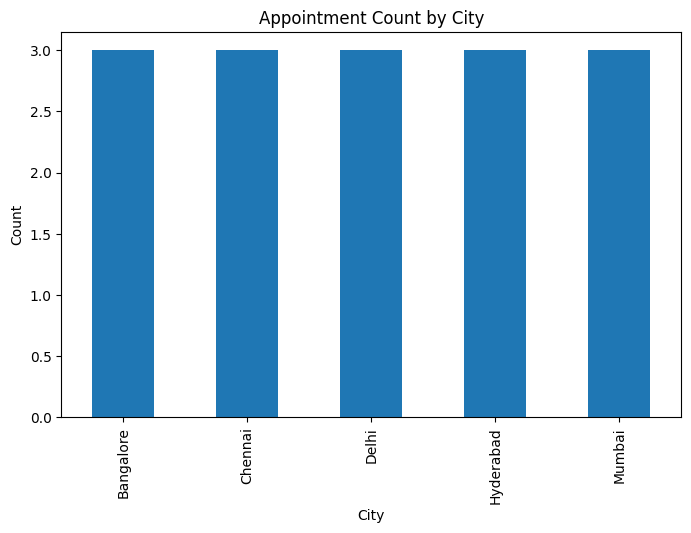

In [0]:
import matplotlib.pyplot as plt

city_count = pdf.groupby("city").size()

plt.figure(figsize=(8,5))
city_count.plot(kind="bar")
plt.title("Appointment Count by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

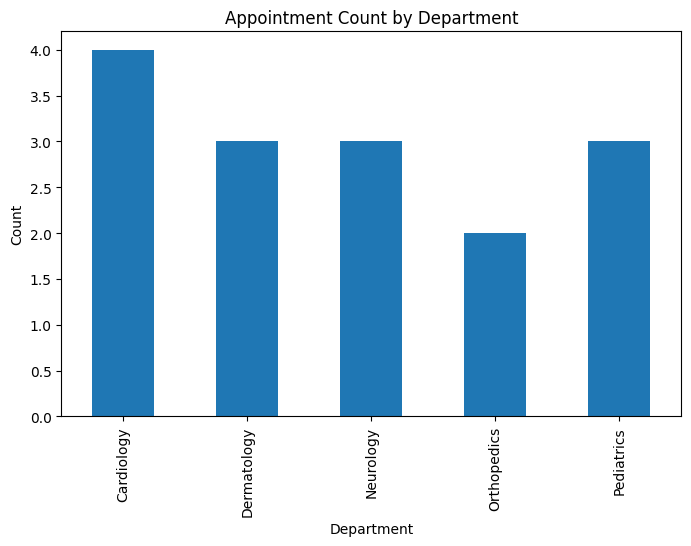

In [0]:
dept_count = pdf.groupby("department").size()

plt.figure(figsize=(8,5))
dept_count.plot(kind="bar")
plt.title("Appointment Count by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

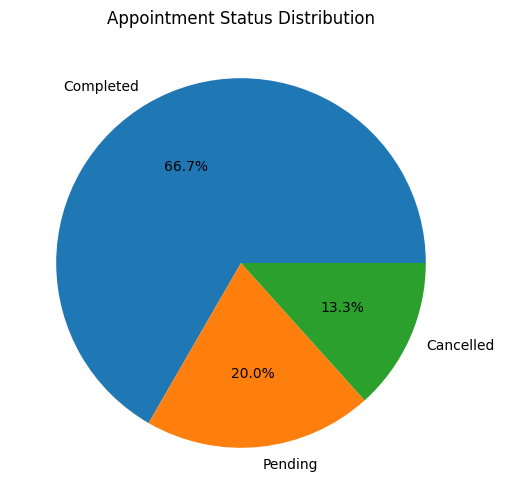

In [0]:
plt.figure(figsize=(6,6))
pdf["status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Appointment Status Distribution")
plt.ylabel("")
plt.show()

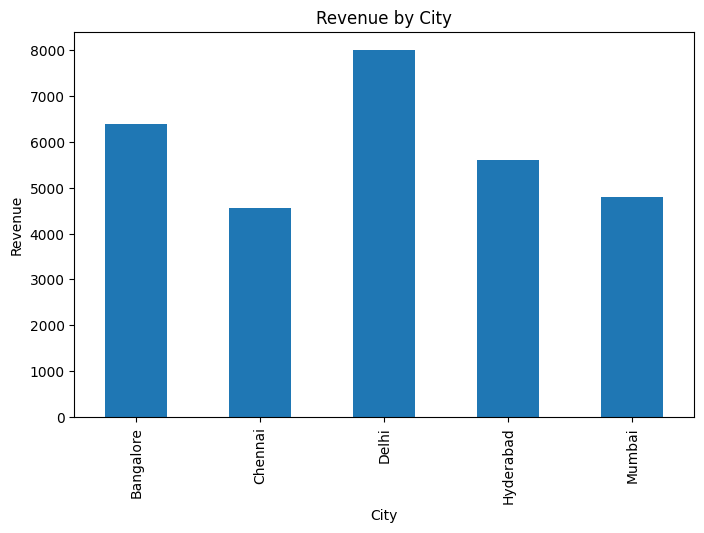

In [0]:
city_revenue = pdf.groupby("city")["consultation_fee"].sum()

plt.figure(figsize=(8,5))
city_revenue.plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

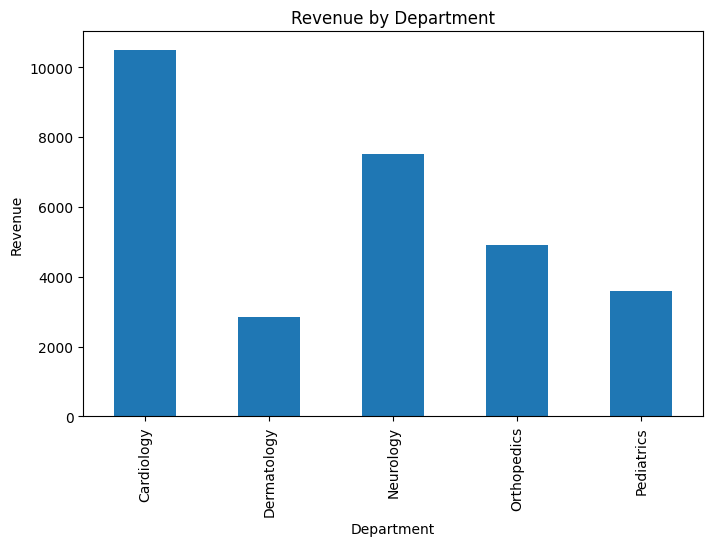

In [0]:
dept_revenue = pdf.groupby("department")["consultation_fee"].sum()

plt.figure(figsize=(8,5))
dept_revenue.plot(kind="bar")
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.show()

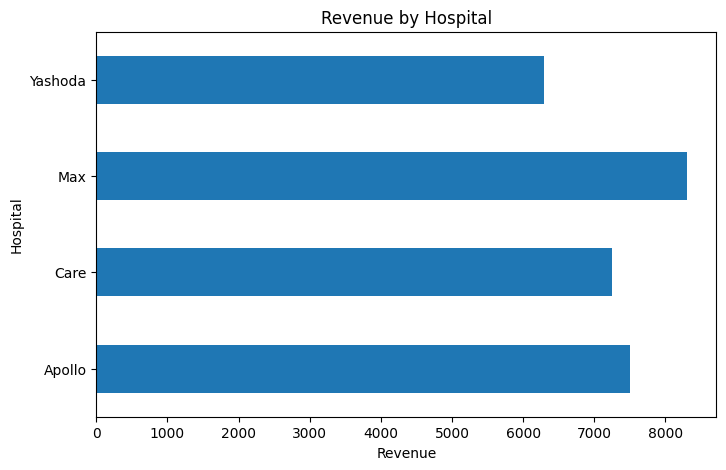

In [0]:
hospital_revenue = pdf.groupby("hospital")["consultation_fee"].sum()

plt.figure(figsize=(8,5))
hospital_revenue.plot(kind="barh")
plt.title("Revenue by Hospital")
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.show()

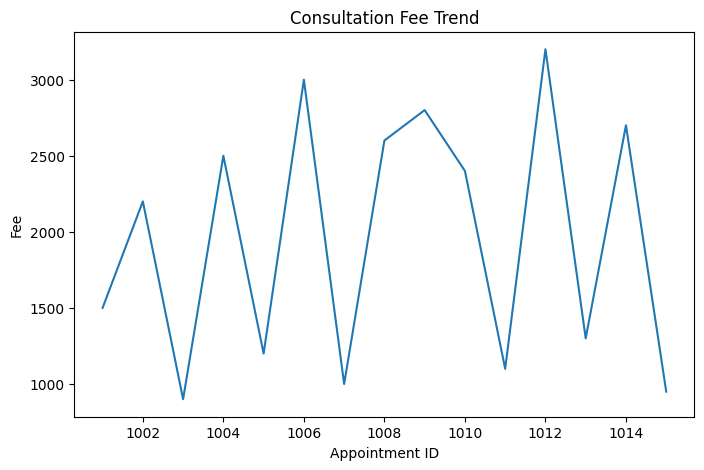

In [0]:
plt.figure(figsize=(8,5))

plt.plot(
    pdf["appointment_id"],
    pdf["consultation_fee"]
)

plt.title("Consultation Fee Trend")
plt.xlabel("Appointment ID")
plt.ylabel("Fee")
plt.show()

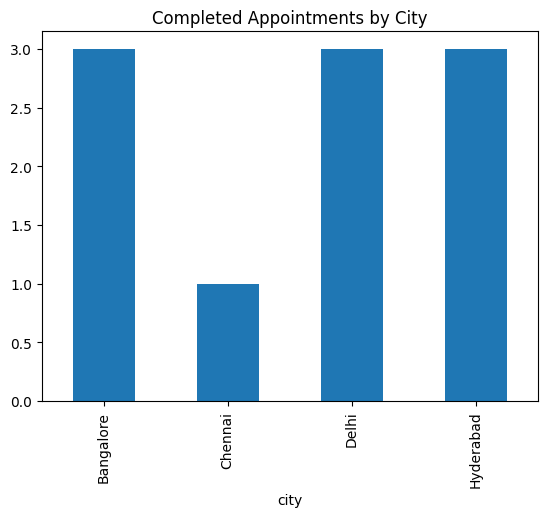

In [0]:
completed = pdf[pdf["status"]=="Completed"]

completed.groupby("city").size().plot(kind="bar")

plt.title("Completed Appointments by City")
plt.show()

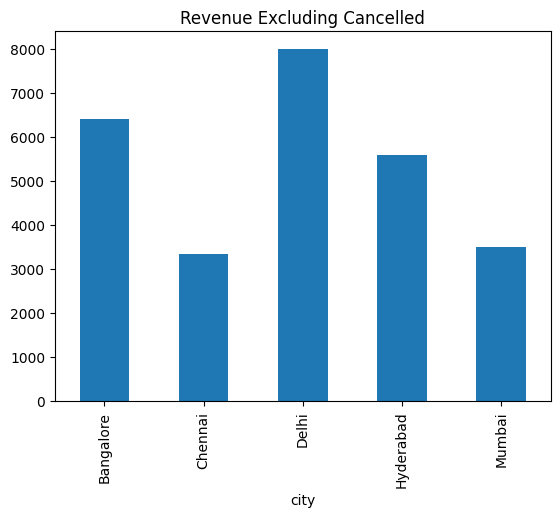

In [0]:
active = pdf[pdf["status"]!="Cancelled"]

active.groupby("city")["consultation_fee"].sum().plot(kind="bar")

plt.title("Revenue Excluding Cancelled")
plt.show()

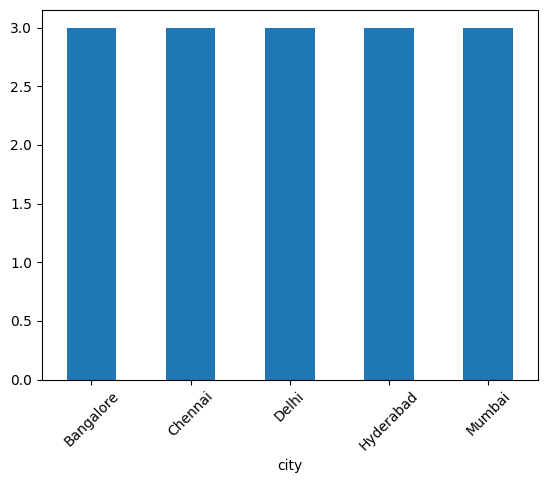

In [0]:
pdf.groupby("city").size().plot(kind="bar")

plt.xticks(rotation=45)

plt.show()

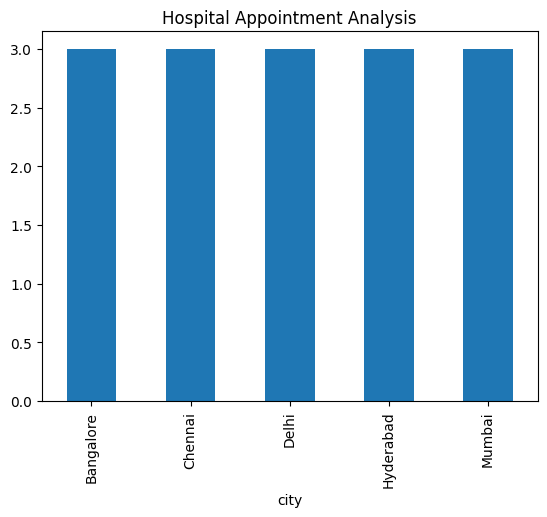

In [0]:
pdf.groupby("city").size().plot(kind="bar")

plt.title("Hospital Appointment Analysis")

plt.show()

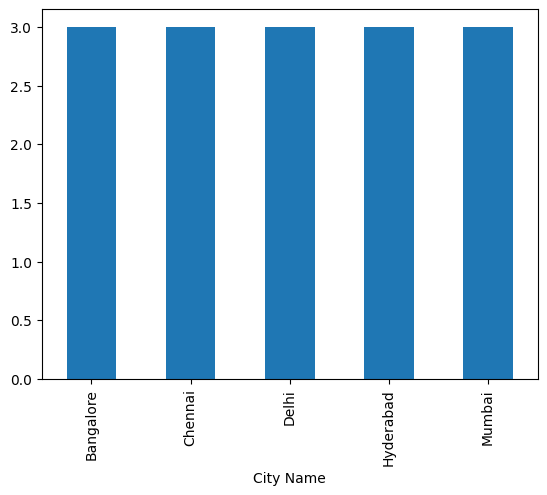

In [0]:
pdf.groupby("city").size().plot(kind="bar")

plt.xlabel("City Name")

plt.show()

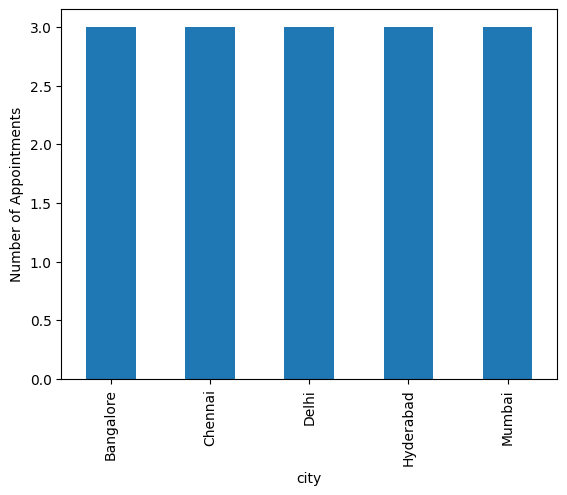

In [0]:
pdf.groupby("city").size().plot(kind="bar")

plt.ylabel("Number of Appointments")

plt.show()

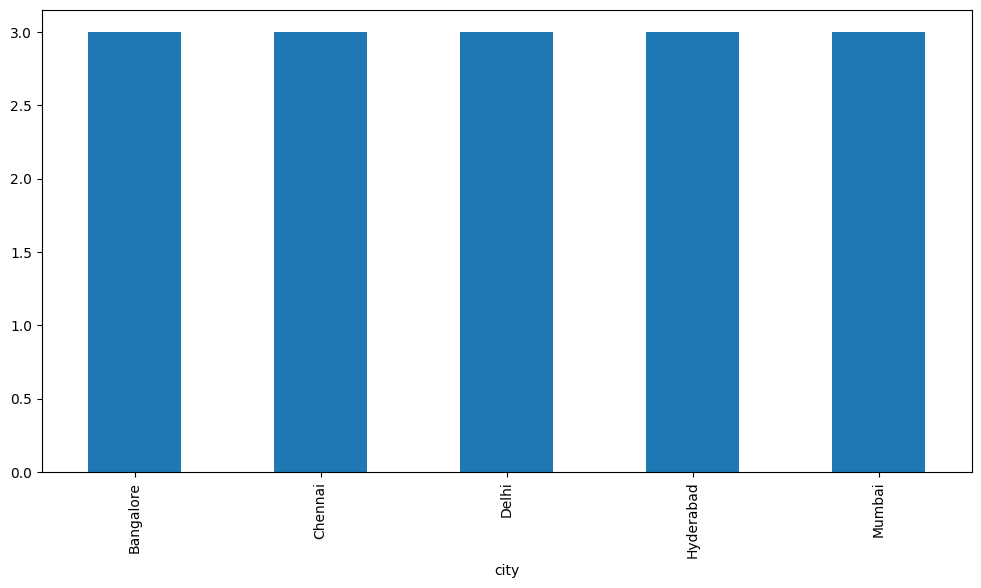

In [0]:
plt.figure(figsize=(12,6))

pdf.groupby("city").size().plot(kind="bar")

plt.show()

In [0]:
top3_city = (
    pdf.groupby("city")["consultation_fee"]
       .sum()
       .sort_values(ascending=False)
       .head(3)
)

print(top3_city)

city
Delhi        8000
Bangalore    6400
Hyderabad    5600
Name: consultation_fee, dtype: int64


In [0]:
top3_department = (
    pdf.groupby("department")["consultation_fee"]
       .sum()
       .sort_values(ascending=False)
       .head(3)
)

print(top3_department)

department
Cardiology     10500
Neurology       7500
Orthopedics     4900
Name: consultation_fee, dtype: int64


In [0]:
lowest_hospital = (
    pdf.groupby("hospital")["consultation_fee"]
       .sum()
       .sort_values()
       .head(1)
)

print(lowest_hospital)

hospital
Yashoda    6300
Name: consultation_fee, dtype: int64


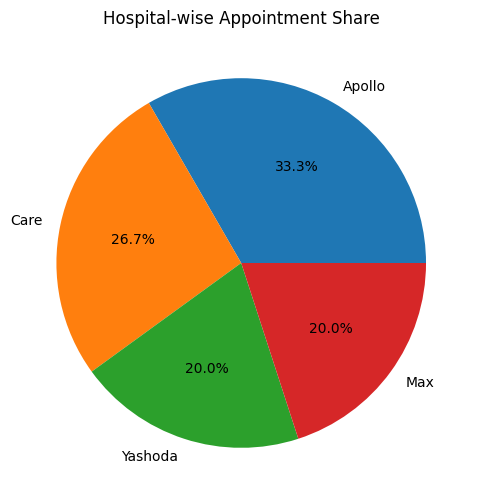

In [0]:
plt.figure(figsize=(6,6))

pdf["hospital"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Hospital-wise Appointment Share")
plt.ylabel("")

plt.show()